In [22]:
import pandas as pd
pd.set_option("display.max_rows", 200)   # show all rows
pd.set_option("display.max_columns", 200) # show all columns

def move_column(df, col_name, new_position):
    assert col_name in df.columns, "Column not found in DataFrame"
    assert 0 <= new_position < len(df.columns), "New position out of bounds"
    cols = df.columns.tolist()
    cols.insert(new_position, cols.pop(cols.index(col_name)))
    return df[cols]

from typing import Any, Dict, Iterable, Iterator, Tuple, Callable, Optional
import pandas as pd
from copy import deepcopy

class DFStruct:
    def __init__(self, drop_for_training: Optional[Iterable[str]] = None):
        self._store: Dict[Tuple[Tuple[str, Any], ...], pd.DataFrame] = {}
        self._train_exclude = set(drop_for_training or
                                  ["OASISID", "seg_days", "cdr_days", "delta_days", "CDRTOT"])

    # ---------- internals ----------
    def _norm_key(self, kwargs: Dict[str, Any]) -> Tuple[Tuple[str, Any], ...]:
        return tuple(sorted(kwargs.items()))

    def _drop_cols(self, df: pd.DataFrame, extra_drop: Optional[Iterable[str]] = None) -> pd.DataFrame:
        cols = self._train_exclude.union(extra_drop or [])
        return df.drop(columns=list(cols), errors="ignore")

    # ---------- core API ----------
    def __call__(self, **kwargs) -> pd.DataFrame:
        return self._store[self._norm_key(kwargs)]

    def add(self, df: pd.DataFrame, **kwargs) -> None:
        self._store[self._norm_key(kwargs)] = df

    def filter(self, **kwargs) -> Iterator[Tuple[Tuple[Tuple[str, Any], ...], pd.DataFrame]]:
        for key, df in self._store.items():
            if all(item in dict(key).items() for item in kwargs.items()):
                yield key, df

    def apply(self, func: Callable[[pd.DataFrame], pd.DataFrame], **kwargs) -> None:
        for key, df in self.filter(**kwargs):
            self._store[key] = func(df)

    # ---------- training helpers ----------
    def get_for_training(self, *, extra_drop: Optional[Iterable[str]] = None,
                         copy_df: bool = True, **kwargs) -> pd.DataFrame:
        df = self(**kwargs)
        df = df.copy(deep=True) if copy_df else df
        return self._drop_cols(df, extra_drop=extra_drop)

    def prepare_for_training_inplace(self, *, extra_drop: Optional[Iterable[str]] = None, **kwargs) -> None:
        def _strip(d: pd.DataFrame) -> pd.DataFrame:
            return self._drop_cols(d, extra_drop=extra_drop)
        self.apply(_strip, **kwargs)

    def set_training_drop_columns(self, cols: Iterable[str]) -> None:
        self._train_exclude = set(cols)

    def add_training_drop_columns(self, cols: Iterable[str]) -> None:
        self._train_exclude.update(cols)

    # ---------- key inspection ----------
    def keys_raw(self) -> list[tuple[tuple[str, Any], ...]]:
        return list(self._store.keys())

    def keys_dict(self) -> list[dict[str, Any]]:
        return [dict(k) for k in self._store.keys()]

    def flag_space(self) -> dict[str, set]:
        out: dict[str, set] = {}
        for k in self._store.keys():
            for name, val in k:
                out.setdefault(name, set()).add(val)
        return out

In [23]:
import os
import pickle

# Default save path
dfs_path = "data/dfs.pkl"

if os.path.exists(dfs_path):
    print(f"Loading existing DFStruct from {dfs_path}")
    with open(dfs_path, "rb") as f:
        dfs = pickle.load(f)
else:
    print("No existing DFStruct found — building from scratch.")
    

Loading existing DFStruct from data/dfs.pkl


In [24]:
dfs.flag_space()

{'allowed_outliers': {10, 20, 5, None},
 'linking': {'bias', 'closest'},
 'num_cats': {2, 3},
 'sigma': {3, 4, 5, None},
 'threshold': {False, True},
 'tiv_norm': {False, True},
 'vent_csf': {False, True}}

# PCA

In [35]:
df = dfs(
    threshold=False, 
    linking="bias", 
    tiv_norm=False, 
    num_cats=3, 
    sigma=3, 
    allowed_outliers=20, 
    vent_csf=True)
df['CDR'].value_counts()

CDR
CN     2078
MCI     793
AD      394
Name: count, dtype: int64

In [41]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from sklearn.metrics import silhouette_score

df = dfs(
    threshold=False, 
    linking="bias", 
    tiv_norm=False, 
    num_cats=3, 
    sigma=3, 
    allowed_outliers=20, 
    vent_csf=False).copy()

N_COMP = 30  # max number of PCs to compute

# ---- 1) Select segmentation features (drop non-seg columns) ----
ignore_cols = {"OASISID","seg_days","cdr_days","delta_days","CDRTOT","CDR"}  # keep CDR aside as labels
id_and_ignore = [c for c in ignore_cols if c in df.columns]

y = df["CDR"].astype(str)  # categorical labels for evaluation/plotting
X = df.drop(columns=id_and_ignore, errors="ignore")

# keep only numeric cols (in case something sneaks in)
X = X.select_dtypes(include=[np.number])

# ---- 2) Standardize ----
scaler = StandardScaler()
Z = scaler.fit_transform(X)    # Z: standardized features

# ---- 3) PCA ----
pca = PCA(n_components=min(N_COMP, Z.shape[1]))  # cap to 30 PCs (tune if you like)
PC = pca.fit_transform(Z)

pc_cols = [f"PC{i+1}" for i in range(PC.shape[1])]
df_pca = pd.DataFrame(PC, columns=pc_cols)
df_pca["CDR"] = y.values

# ---- 4) Which PCs relate most to CDR? (one-way ANOVA across CDR groups) ----
# ANOVA F-test per PC treating CDR as categories
F, p = f_classif(df_pca[pc_cols], df_pca["CDR"])
pc_assoc = (
    pd.DataFrame({"PC": pc_cols, "F": F, "p": p})
      .sort_values("F", ascending=False)
      .reset_index(drop=True)
)

pc_assoc['p_adj'] = pc_assoc['p'] * N_COMP  # Bonferroni correction
pc_assoc['significant'] = pc_assoc['p_adj'] < 0.05

# Choose the top PC (highest F) as your "CDR-aligned" PCA axis
best_pc = pc_assoc.iloc[0, 0]           # e.g., "PC2"
best_pc_idx = pc_cols.index(best_pc)    # integer index

# ---- 5) Per-scan "CDR score" from PCA ----
# This is just the coordinate along that best PC.
seg_with_pca_score = df.copy()
seg_with_pca_score["pca_cdr_score"] = df_pca[best_pc].values

# ---- 6) Optional: quantify separation in PC space ----
sil_all = silhouette_score(df_pca[pc_cols[:2]], y)  # silhouette on first 2 PCs (quick sanity check)
# You can also compute ANOVA F or silhouette on more PCs / best subset.

# ---- 7) Region-level contributions (loadings) for the chosen PC ----
# Loadings (contribution of each region to the PC) in standardized space:
# common definition: loadings = components_.T * sqrt(explained_variance_)
loadings = pca.components_[best_pc_idx] * np.sqrt(pca.explained_variance_[best_pc_idx])
loadings = pd.Series(loadings, index=X.columns, name="loading")
loadings_abs_ranked = loadings.abs().sort_values(ascending=False)

# Now you have:
# - seg_with_pca_score["pca_cdr_score"]  -> one scalar per scan
# - pc_assoc (which PCs relate to CDR)
# - loadings (per-region attribution for the chosen PC)
# - sil_all (rough separation metric on PCs)


In [42]:
pc_assoc

,PC,F,p,p_adj,significant
0,PC3,388.499037,4.522686e-152,1.356806e-150,True
1,PC1,103.458930,2.725778e-44,8.177333e-43,True
2,PC10,41.375550,1.798455e-18,5.395365e-17,True
3,PC2,29.107621,2.952324e-13,8.856973e-12,True
4,PC11,25.306647,1.241166e-11,3.723499e-10,True
5,PC17,23.414051,8.010918e-11,2.403275e-09,True
6,PC6,23.288515,9.066349e-11,2.719905e-09,True
7,PC24,20.332391,1.676197e-09,5.028591e-08,True
8,PC9,17.971068,1.729562e-08,5.188685e-07,True
9,PC5,14.462365,5.581484e-07,1.674445e-05,True


In [43]:
sil_all # silhouette score with CDR across all samples on the first 2 PCs

-0.038764123476705416

<Axes: >

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

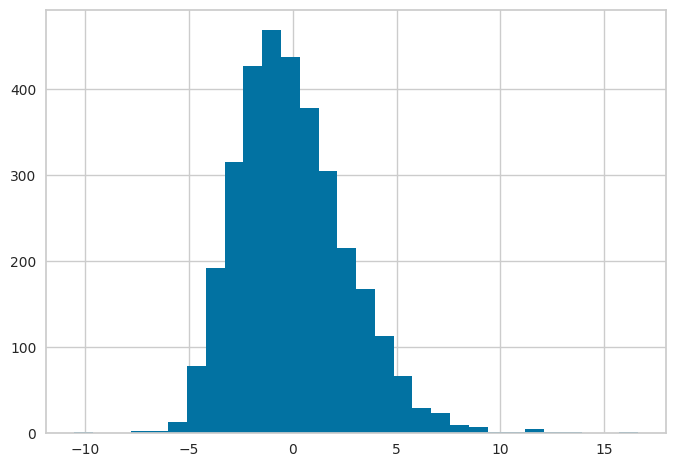

In [44]:
seg_with_pca_score["pca_cdr_score"].hist(bins=30)

In [45]:
loadings_abs_ranked.head(10) # top 10 regions contributing to the chosen PC

Left th_mediodorsal           0.628251
Right th_mediodorsal          0.531731
Right th_intralaminar         0.494554
Left th_intralaminar          0.488748
Left th_anterior              0.454933
Left PIns posterior insula    0.445429
Right Pallidum                0.437874
Left th_posteriorAnterior     0.421977
Left Pallidum                 0.417362
Left th_pulvinar              0.396927
Name: loading, dtype: float64

In [ ]:
# train/test split
# PLS regression with train
# evaluate on test with loadings vs CDR correlation

In [ ]:
# factor analysis
# 

# PLS regression approach

In [46]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

df = dfs(
    threshold=False, 
    linking="bias", 
    tiv_norm=False, 
    num_cats=3, 
    sigma=3, 
    allowed_outliers=20, 
    vent_csf=True).copy()

# Encode CDR ordinally
cdr_map = {"CN": 0, "MCI": 1, "AD": 2}
y_ord = df["CDR"].map(cdr_map).values

# Drop non-segmentation columns
ignore_cols = {"OASISID","seg_days","cdr_days","delta_days","CDRTOT","CDR"}
region_cols = [c for c in df.columns if c not in ignore_cols]

X = df[region_cols].astype(float)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PLS with 1 component (best single axis for severity)
pls = PLSRegression(n_components=1)
pls.fit(X_scaled, y_ord)

# Per-scan score
df["cdr_score_pls"] = pls.transform(X_scaled).ravel()

# Region contributions (loadings * coef)
region_weights = pd.Series(pls.x_weights_.ravel(), index=region_cols, name="weight")
region_weights = region_weights.sort_values(key=np.abs, ascending=False)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

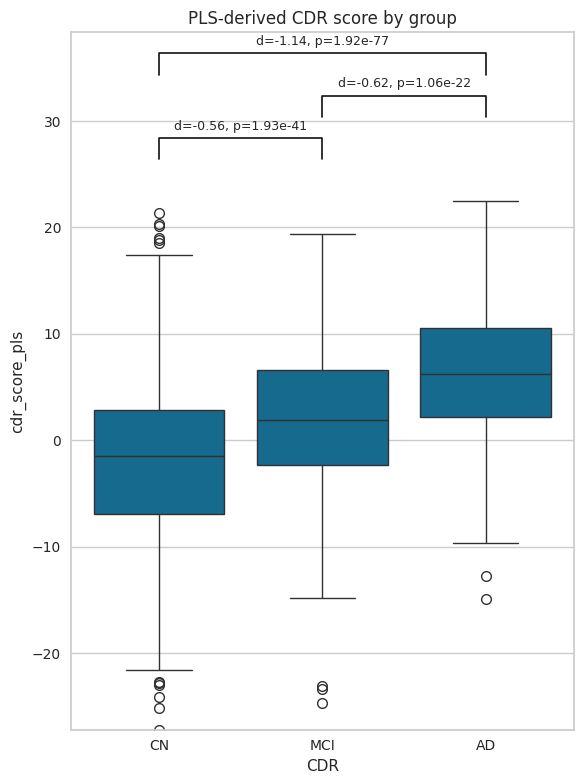

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.var(x, ddof=1) + (ny-1)*np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

order = ["CN", "MCI", "AD"]
pairs = [("CN","MCI"), ("MCI","AD"), ("CN","AD")]

fig, ax = plt.subplots(figsize=(6,8))
sns.boxplot(x="CDR", y="cdr_score_pls", data=df, order=order, ax=ax)
ax.set_title("PLS-derived CDR score by group")

# vertical spacing for annotations
y_min, y_max = df["cdr_score_pls"].min(), df["cdr_score_pls"].max()
y_span = y_max - y_min if y_max > y_min else 1.0
y_offset = 0.08 * y_span  # space between stacked brackets

for i, (g1, g2) in enumerate(pairs):
    x1, x2 = order.index(g1), order.index(g2)

    x = df.loc[df["CDR"]==g1, "cdr_score_pls"].values
    y = df.loc[df["CDR"]==g2, "cdr_score_pls"].values

    d = cohens_d(x, y)
    t, p = ttest_ind(x, y, equal_var=False)   # Welch's t-test

    y_line = y_max + (i+1)*y_offset
    ax.plot([x1, x1, x2, x2], [y_line, y_line + 0.04*y_span, y_line + 0.04*y_span, y_line],
            lw=1.2, c='k')
    ax.text((x1 + x2) / 2, y_line + 0.05*y_span, f"d={d:.2f}, p={p:.3g}",
            ha='center', va='bottom', fontsize=9)

# expand ylim so annotations are visible
ax.set_ylim(y_min, y_max + (len(pairs)+1)*y_offset)
plt.tight_layout()
plt.show()

PLS-derived scores increased monotonically with CDR severity. Pairwise comparisons were highly significant (all p < 1e-10). Effect sizes were medium for adjacent groups (Cohen’s d ≈ 0.6) and large between no_CI and CI (d ≈ 1.2).

In [48]:
# region contributions (3 flavors)

# 1) Weights (direction defining the latent axis)
weights = pd.Series(pls.x_weights_[:, 0], index=region_cols, name="weight")

# 2) Loadings from sklearn (how each region relates to the X-score)
loadings = pd.Series(pls.x_loadings_[:, 0], index=region_cols, name="loading")

# 3) Regression coefficients (mapping X -> encoded CDR)
coefs = pd.Series(pls.coef_.ravel(), index=region_cols, name="coef")


In [49]:
weights_abs = weights.abs().sort_values(ascending=False)
loadings_abs = loadings.abs().sort_values(ascending=False)

In [50]:
loadings_abs

Left FuG fusiform gyrus              0.113803
Right PHG parahippocampal gyrus      0.113675
Right FuG fusiform gyrus             0.113173
Right Ent entorhinal area            0.112643
Right ITG inferior temporal gyrus    0.111942
                                       ...   
Left agd_astr                        0.009801
Right vessel                         0.009801
Left vessel                          0.009801
Right agd_centromedian               0.009801
Left agd_centromedian                0.008531
Name: loading, Length: 166, dtype: float64

In [51]:
# Regions most associated with CDR according to PLS weights
weights_abs.head(10)

Right Inf Lat Vent         0.177437
Left Inf Lat Vent          0.177018
Right th_intralaminar      0.153558
Left th_intralaminar       0.149517
Left th_anterior           0.146308
Right agd_laterobasal      0.144814
Left agd_laterobasal       0.144231
Left th_mediodorsal        0.143610
Left Lateral Ventricle     0.143420
Right Lateral Ventricle    0.141383
Name: weight, dtype: float64

In [52]:
weights.sort_values(ascending=False).head(14)

Right Inf Lat Vent            0.177437
Left Inf Lat Vent             0.177018
Left Lateral Ventricle        0.143420
Right Lateral Ventricle       0.141383
CSF                           0.133782
3rd Ventricle                 0.133527
4th Ventricle                 0.073686
Left PIns posterior insula    0.044890
Left agd_centromedian         0.038488
Right agd_astr                0.038477
Right agd_centromedian        0.038477
Left vessel                   0.038477
Right vessel                  0.038477
Left agd_astr                 0.038477
Name: weight, dtype: float64

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


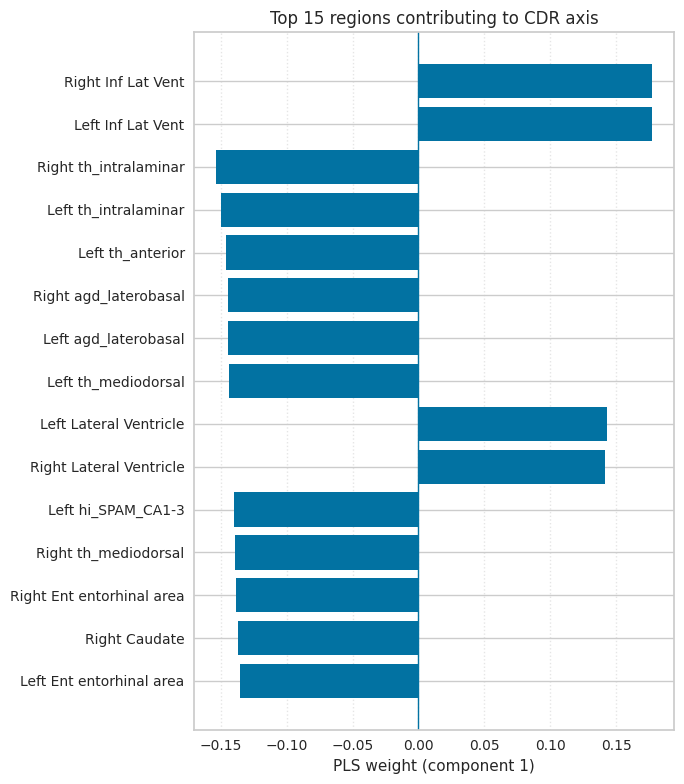

In [53]:
# weights: pd.Series of shape (n_regions,), e.g. pd.Series(pls.x_weights_[:,0], index=region_cols)
topk = 15
w_abs = weights.abs().sort_values(ascending=False)
top = w_abs.head(topk).index
vals = weights.loc[top]

fig, ax = plt.subplots(figsize=(7, 0.4*topk + 2))
ypos = np.arange(len(top))[::-1]
ax.barh(ypos, vals.loc[top])
ax.set_yticks(ypos)
ax.set_yticklabels(top)
ax.set_xlabel("PLS weight (component 1)")
ax.set_title(f"Top {topk} regions contributing to CDR axis")
ax.axvline(0, linewidth=1)
ax.grid(True, axis="x", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

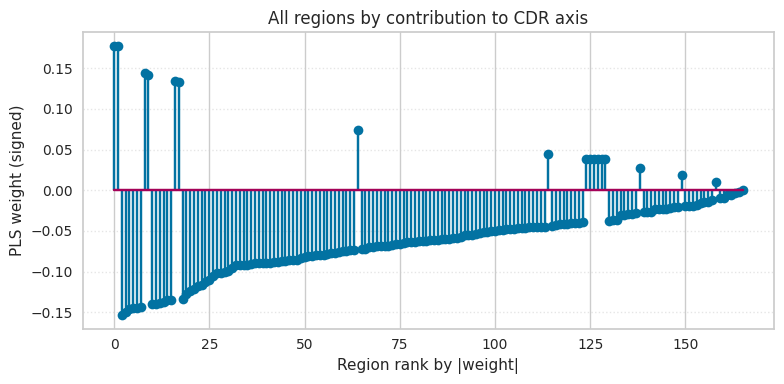

In [54]:
w_sorted = weights.sort_values(key=np.abs, ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
ax.stem(range(len(w_sorted)), w_sorted.values, use_line_collection=True)
ax.set_xlabel("Region rank by |weight|")
ax.set_ylabel("PLS weight (signed)")
ax.set_title("All regions by contribution to CDR axis")
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
"""# After fitting pls = PLSRegression(n_components=2) and transforming:
scores_2d = pls.transform(X_scaled)  # shape (n_samples, 2)

fig, ax = plt.subplots(figsize=(6,5))
colors = {"no_CI": "C0", "mild_CI": "C1", "CI": "C2"}
for g in order:
    m = df["_CDR_ord"] == g
    ax.scatter(scores_2d[m, 0], scores_2d[m, 1], s=18, alpha=0.7, label=g)

ax.set_xlabel("PLS component 1")
ax.set_ylabel("PLS component 2")
ax.set_title("PLS scores (2 components)")
ax.legend(frameon=False)
ax.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()
"""

'# After fitting pls = PLSRegression(n_components=2) and transforming:\nscores_2d = pls.transform(X_scaled)  # shape (n_samples, 2)\n\nfig, ax = plt.subplots(figsize=(6,5))\ncolors = {"no_CI": "C0", "mild_CI": "C1", "CI": "C2"}\nfor g in order:\n    m = df["_CDR_ord"] == g\n    ax.scatter(scores_2d[m, 0], scores_2d[m, 1], s=18, alpha=0.7, label=g)\n\nax.set_xlabel("PLS component 1")\nax.set_ylabel("PLS component 2")\nax.set_title("PLS scores (2 components)")\nax.legend(frameon=False)\nax.grid(True, linestyle=":", alpha=0.5)\nplt.tight_layout()\nplt.show()\n'